# Breakdowns — chemistry & cell line

Per-slice ranking skill with sample counts and inhibition ranges, so a strong number can't
hide in a narrow-variance slice. Reads the same `results/` (see `_viz.py`).

In [1]:
import _viz as v
v.setup_style()
import numpy as np, pandas as pd, matplotlib.pyplot as plt
R = v.load_results()
summary, preds = R['summary'], v.add_cohort_mean(R['preds'])
breakdown = R['breakdown']
print('test oligos:', len(preds), '| patent cohorts:', preds.custom_id.nunique(), '| scorers:', summary.scorer.nunique())

test oligos: 20846 | patent cohorts: 269 | scorers: 11


## Per chemistry — cEt vs 2'MOE gapmers
Bar = median per-cohort Spearman; dots = the per-cohort distribution; black tick = mean (μ).

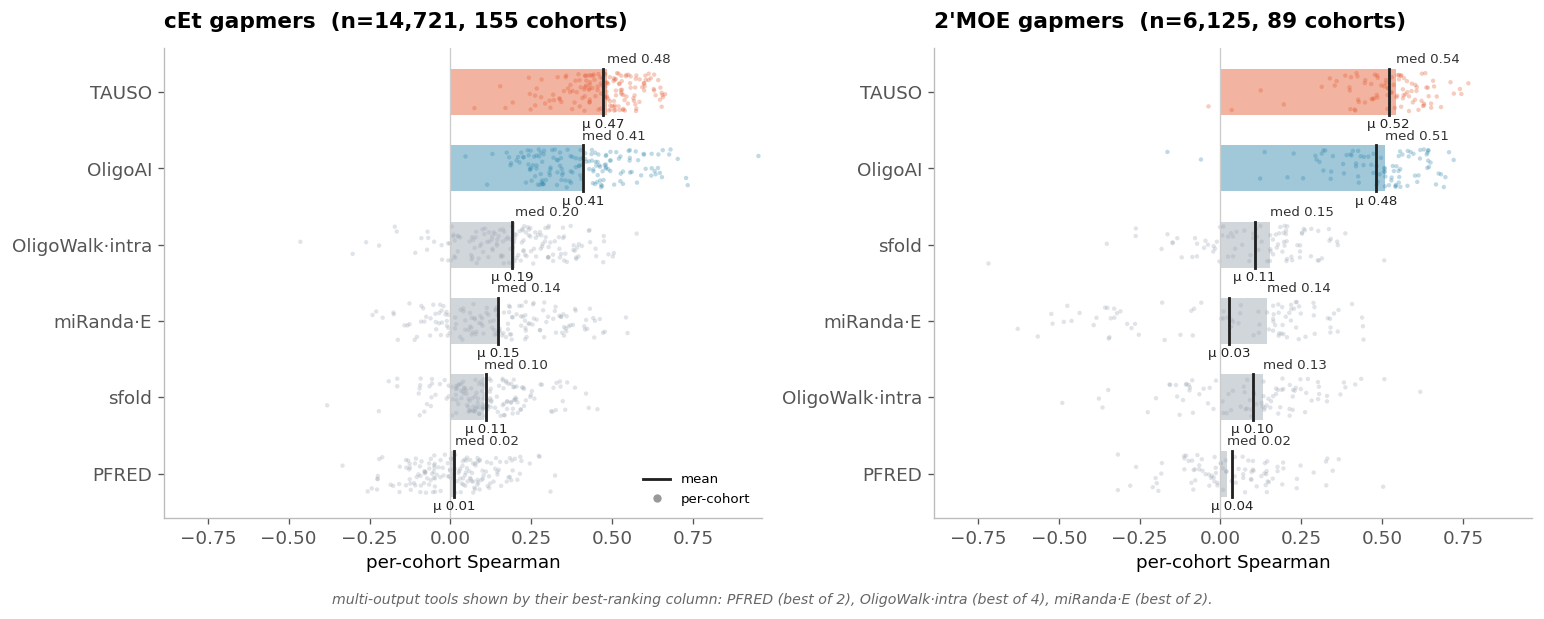

In [2]:
from matplotlib.lines import Line2D
chem = breakdown[breakdown.breakdown=='chemistry']
reps, note = v.best_representatives(summary)
show = v.SINGLES + reps
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for a, cv in zip(ax, ["cEt", "2'MOE"]):
    sub = preds[preds.chemistry==cv]
    dist = {s: v.per_cohort_spearman(sub, s) for s in show}
    o = sorted([s for s in show if len(dist[s])], key=lambda s: (s!='TAUSO', -np.median(dist[s])))
    v.hbar_dist(a, o, [np.median(dist[s]) for s in o], [np.mean(dist[s]) for s in o], [dist[s] for s in o],
                title=f'{cv} gapmers  (n={len(sub):,}, {dist["TAUSO"].size} cohorts)', xlabel='per-cohort Spearman')
ax[0].legend(handles=[Line2D([0],[0],color='#222',lw=1.7,label='mean'),
                      Line2D([0],[0],marker='o',color='w',markerfacecolor='#999',markersize=6,label='per-cohort')],
             frameon=False, fontsize=8, loc='lower right')
fig.text(0.5, -0.02, v.rep_caption(note), ha='center', fontsize=8.5, color='#666', style='italic')
plt.tight_layout(); plt.show()

In [3]:
# descriptive + TAUSO/OligoAI per chemistry
desc = chem.drop_duplicates('slice').set_index('slice')[['n_samples','n_genes','n_patents','inhib_mean','base_hit70']]
for s in ['TAUSO','oligo_ai_score']:
    desc[v.disp(s)] = chem[chem.scorer==s].set_index('slice')['spearman_median']
desc.round({'inhib_mean':1,'base_hit70':3,'TAUSO':3,'OligoAI':3})

,n_samples,n_genes,n_patents,inhib_mean,base_hit70,TAUSO,OligoAI
slice,,,,,,,
2'MOE,6125,20,127,53.4,0.342,0.541,0.508
cEt,14721,6,177,42.9,0.227,0.484,0.405


## Per cell line
Sorted by sample count; **HUVEC** is tiny in test and excluded by the cohort threshold — fine to miss.

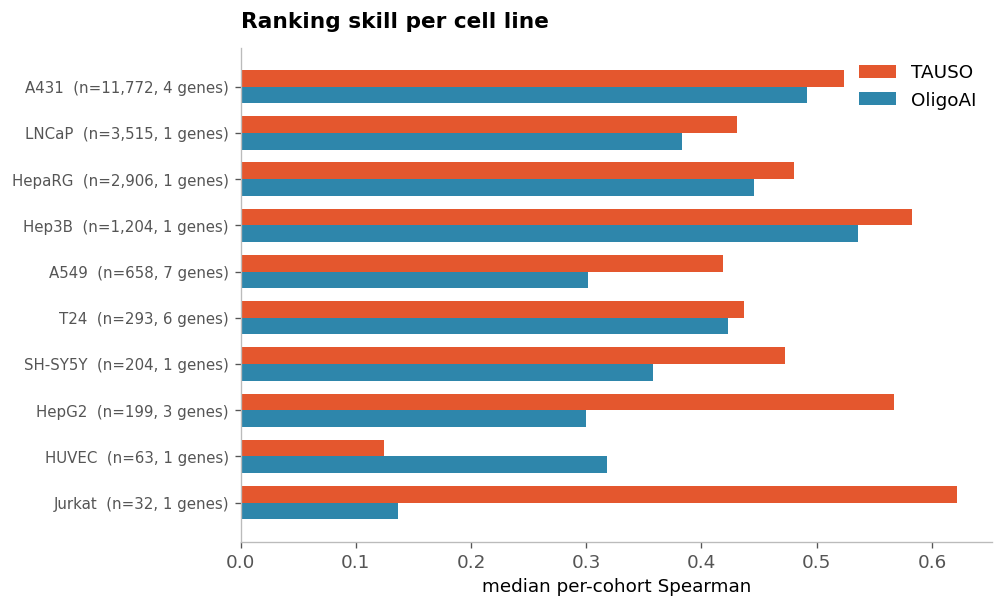

In [4]:
cell = breakdown[breakdown.breakdown=='Cell_line']
ta = cell[cell.scorer=='TAUSO'].set_index('slice').sort_values('n_samples', ascending=False)
oa = cell[cell.scorer=='oligo_ai_score'].set_index('slice')['spearman_median']
fig, ax = plt.subplots(figsize=(8.5, 5.2))
y = np.arange(len(ta))[::-1]
ax.barh(y+.18, ta['spearman_median'].values, .36, color=v.ACCENT, label='TAUSO')
ax.barh(y-.18, oa.reindex(ta.index).values, .36, color=v.BLUE, label='OligoAI')
ax.set_yticks(y); ax.set_yticklabels([f'{c}  (n={int(n):,}, {int(g)} genes)' for c, n, g in zip(ta.index, ta.n_samples, ta.n_genes)], fontsize=9)
ax.set_xlabel('median per-cohort Spearman'); ax.set_title('Ranking skill per cell line'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [5]:
# cell-line table with inhibition range + an A431-excluded aggregate (A431 is ~half the test rows)
tbl = ta[['n_samples','n_genes','n_patents','inhib_min','inhib_max','inhib_mean','base_hit70','spearman_median']].copy()
tbl = tbl.rename(columns={'spearman_median':'TAUSO'}); tbl['OligoAI'] = oa.reindex(tbl.index)
big = tbl[tbl.n_samples>=200]
agg = pd.Series({'n_samples':big.n_samples.sum(),'TAUSO':np.average(big.TAUSO,weights=big.n_patents),'OligoAI':np.average(big.OligoAI.fillna(0),weights=big.n_patents)}, name='—weighted (n≥200)')
no431 = big.drop(index='A431', errors='ignore')
agg2 = pd.Series({'n_samples':no431.n_samples.sum(),'TAUSO':np.average(no431.TAUSO,weights=no431.n_patents),'OligoAI':np.average(no431.OligoAI.fillna(0),weights=no431.n_patents)}, name='—weighted, A431 excluded')
print('Aggregates (patent-weighted over cell lines with n≥200):')
print(pd.DataFrame([agg, agg2])[['n_samples','TAUSO','OligoAI']].round(3).to_string())
tbl.round({'inhib_min':0,'inhib_max':0,'inhib_mean':1,'base_hit70':3,'TAUSO':3,'OligoAI':3})

Aggregates (patent-weighted over cell lines with n≥200):
                          n_samples  TAUSO  OligoAI
—weighted (n≥200)           20552.0  0.494    0.454
—weighted, A431 excluded     8780.0  0.468    0.420


,n_samples,n_genes,n_patents,inhib_min,inhib_max,inhib_mean,base_hit70,TAUSO,OligoAI
slice,,,,,,,,,
A431,11772,4,125,0.0,100.0,48.8,0.309,0.523,0.492
LNCaP,3515,1,47,0.0,99.0,31.8,0.109,0.431,0.383
HepaRG,2906,1,49,0.0,99.0,43.7,0.141,0.480,0.446
Hep3B,1204,1,17,0.0,96.0,50.3,0.288,0.583,0.536
A549,658,7,12,0.0,100.0,63.6,0.500,0.419,0.302
T24,293,6,8,0.0,98.0,63.5,0.519,0.437,0.423
SH-SY5Y,204,1,2,0.0,90.0,38.1,0.167,0.472,0.358
HepG2,199,3,7,0.0,98.0,68.3,0.673,0.567,0.300
HUVEC,63,1,1,0.0,46.0,15.2,0.000,0.124,0.318
